## Methode STIT de Klatt et Lotz


Persistence of asymptotic variance under transport: \
from hyperfluctuation to stealthy hyperuniformity \

cf Page 6 du papier:
https://arxiv.org/pdf/2605.22803


 STIT tessellations = STable with respect to ITerations

In [2]:
#pip install blue_sampler

In [3]:
import blue_sampler as blue
import numpy as np
import matplotlib.pyplot as plt
from blue_sampler.datasets import generate_dataset

In [13]:
def centroids(x):
    """
    x is a batch of quadrilaters of the shape (batch, 4, 2)
    we just compute barycenter for each tesselsrilateral
    """
    return x.mean(axis = 1)

def solve_moment(x, p):
    """
    one can also sample hyperuniform points by solving a moment equation,
    solving moment equality to all orders between 0 and p-1
    to strenghten hyperunformity. This is done by blue.from_geometry wich internaly
    solve the moment equation
    """
    return blue.from_geometry(x, gtype = "polygons", p = p)


def show_polygons(ax, tessels):
    n = len(tessels)
    cmap = plt.cm.YlGnBu

    for i, quad in enumerate(tessels):
        color = cmap(0.2 + 0.8 * (i / n))

        qloop = np.vstack([quad, quad[0]])
        ax.fill(
            qloop[:, 0], qloop[:, 1],
            color=color,
            alpha=0.35,
            edgecolor="#FFFFFF",
            linewidth=1.2,
            zorder=1
        )
    return ax

def show_clusters(ax, clusters):
    n = len(clusters)
    cmap = plt.cm.YlGnBu

    for i, pts in enumerate(clusters):
        color = cmap(0.5 + 0.5 * (i / n))

        ax.scatter(
            pts[:, 0], pts[:, 1],
            s=18,
            color=color,
            alpha=0.9,
            edgecolors="#1A2B3C",
            linewidths=0.3,
            zorder=2
        )
    return ax

def show_result(tessels = None, points = None):
    # --- figure ---
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

    fond_clair = "#FAFAFA"
    fig.patch.set_facecolor(fond_clair)
    ax.set_facecolor(fond_clair)

    if tessels is not None:
        show_polygons(ax, tessels)
    if points is not None:
        show_clusters(ax, points)

    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

## fair STIT allow to sample 1 million tessels in a matter of seconds

here we will sample only 65 000 tessels

In [37]:
tessels = blue.sample_tessels(N = 2**16)

one cannot plot all the tessels (to slow). back merge allow to reverse a tesselation step, thus to plot a reasonable number of tessels

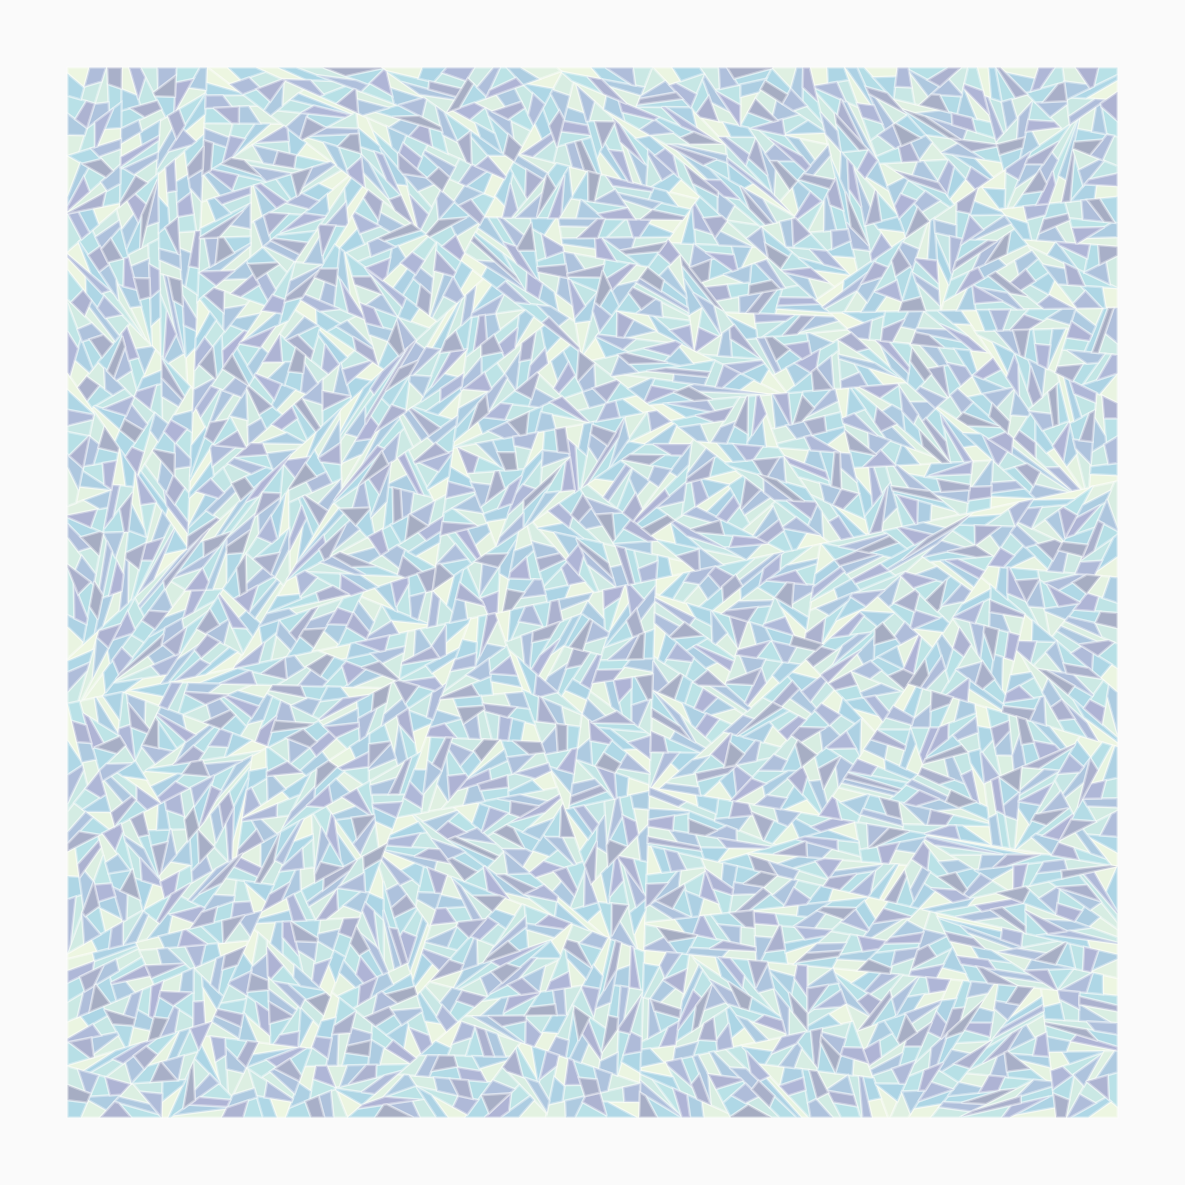

In [27]:
from blue_sampler.run.run_tessels import back_merge_tessels
sub_tessels = tessels
for _ in range(4):
    sub_tessels = back_merge_tessels(sub_tessels)
show_result(sub_tessels) #the full tesselation is much finer, but impossible to plot in a reasonable time

## Now we can sample points well distributed with respect to the tessels


Here we just sample points at the center of each tessel

(65536, 2)


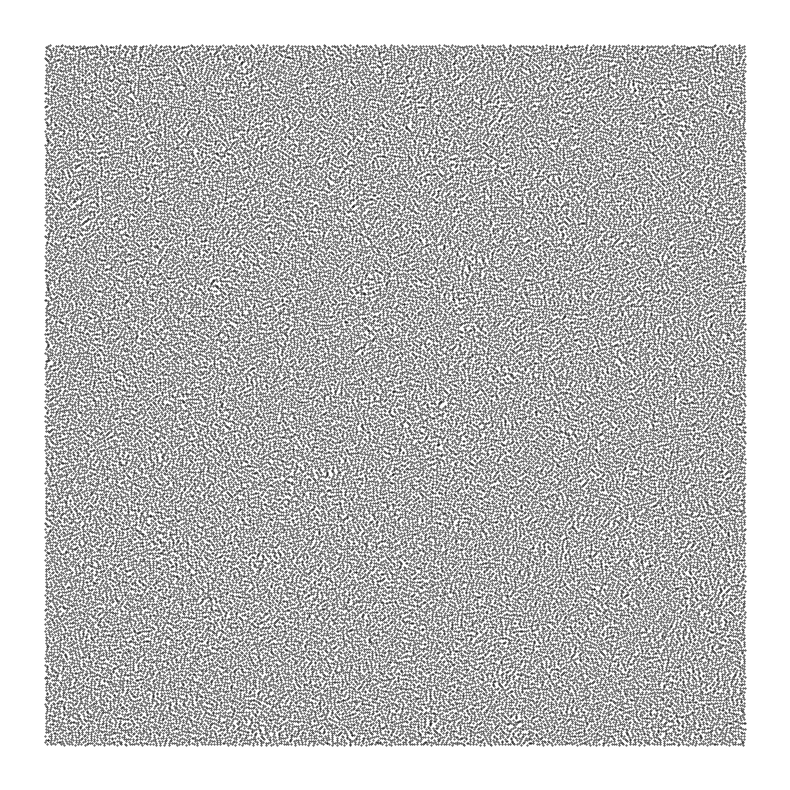

In [28]:
x_center = centroids(tessels)
print(x_center.shape)
blue.plot(x_center)

But one can also solve moment equation, eg solve moment up to order 2 (p = 3). slower but better results

(196608, 2)


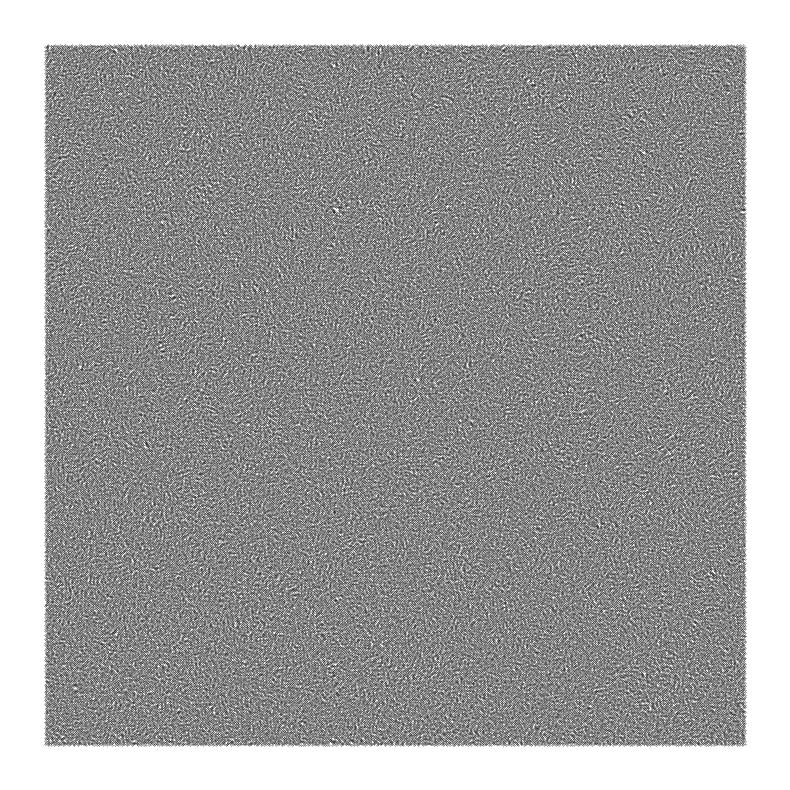

In [7]:
x_moment2 = solve_moment(tessels, p = 3).reshape(-1, 2)
print(x_moment2.shape)
blue.plot(x_moment2)

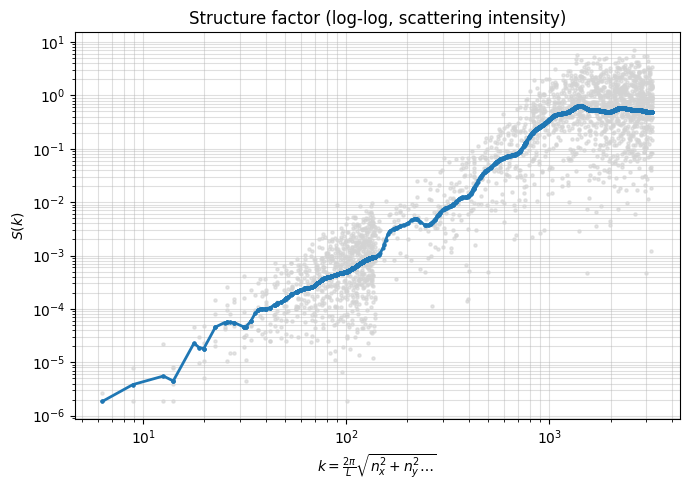

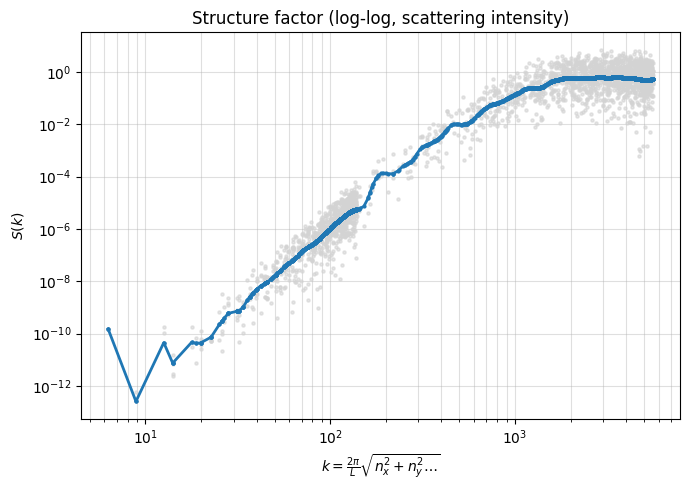

In [8]:
blue.plot_structure_factor(x_center)
blue.plot_structure_factor(x_moment2) #slower but better

To visualize points and tesselation at the same time:

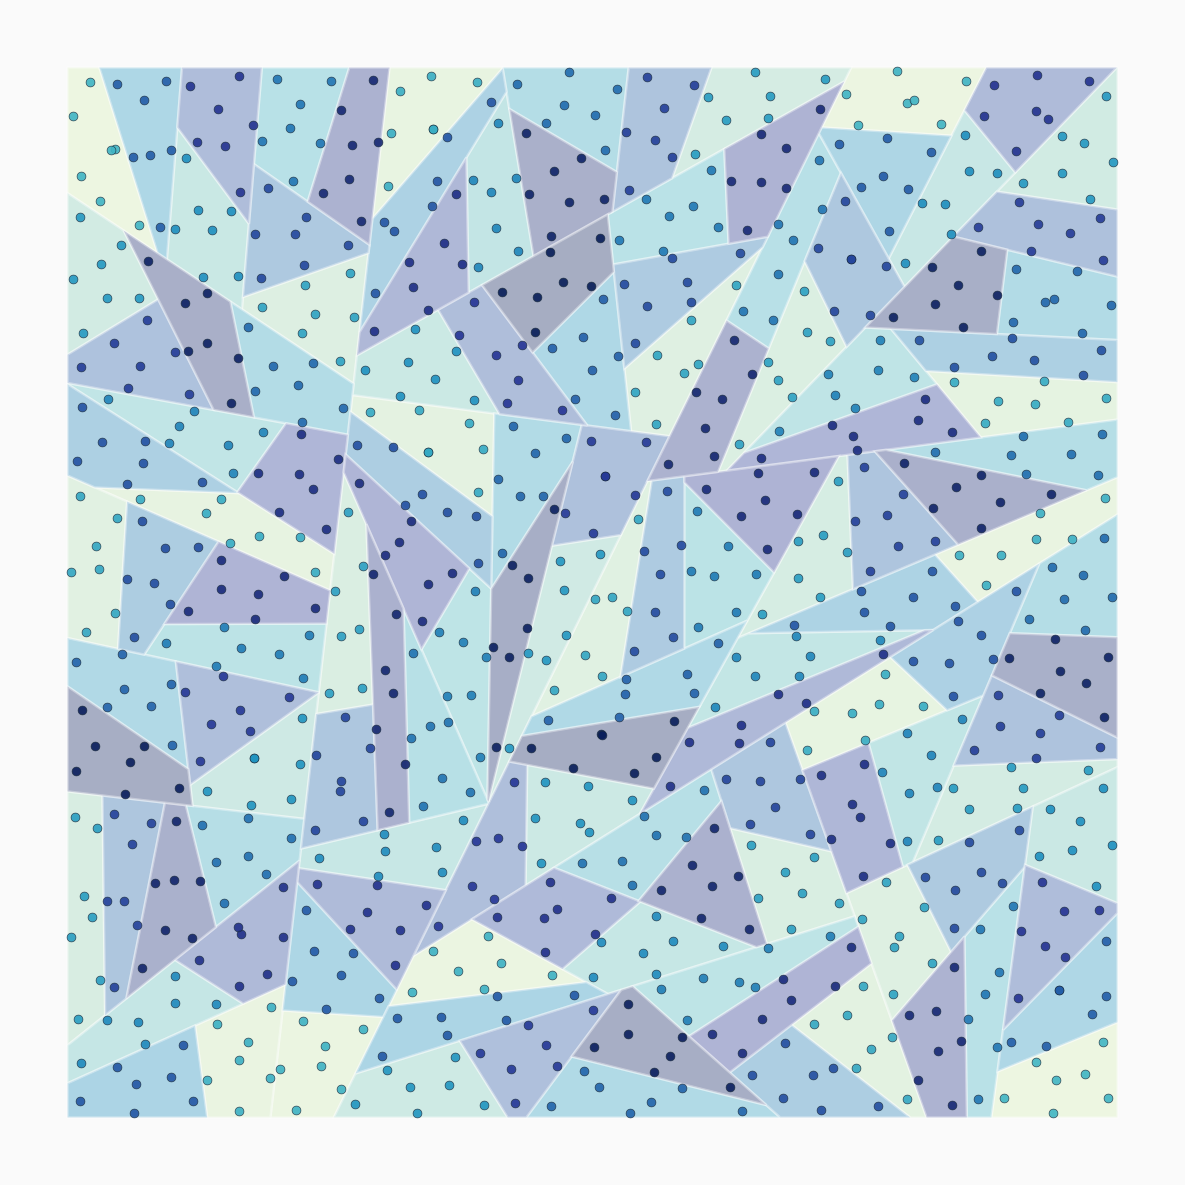

In [36]:
tessels = blue.sample_tessels(N = 2**7)
points = blue.from_geometry(tessels, gtype = "polygons", p = 5)
show_result(tessels, points) #only for small number of points, very slow

## Tessels for adaptative sampling

In [32]:
targets = blue.generate_dataset(size = (2**12*100,2), dataset = "france", plot_data = False)
tessels = blue.sample_tessels(N=2**12, targets = targets)

source: squarenet.sampler from module squarenet
available datasets: {'realdata': ['barbara', 'lena', 'france', 'germany', 'everest'], 'synthetic': ['square', 'ball', 'ring', 'gaussian', 'spiky', 'holy', '4Dloop']}


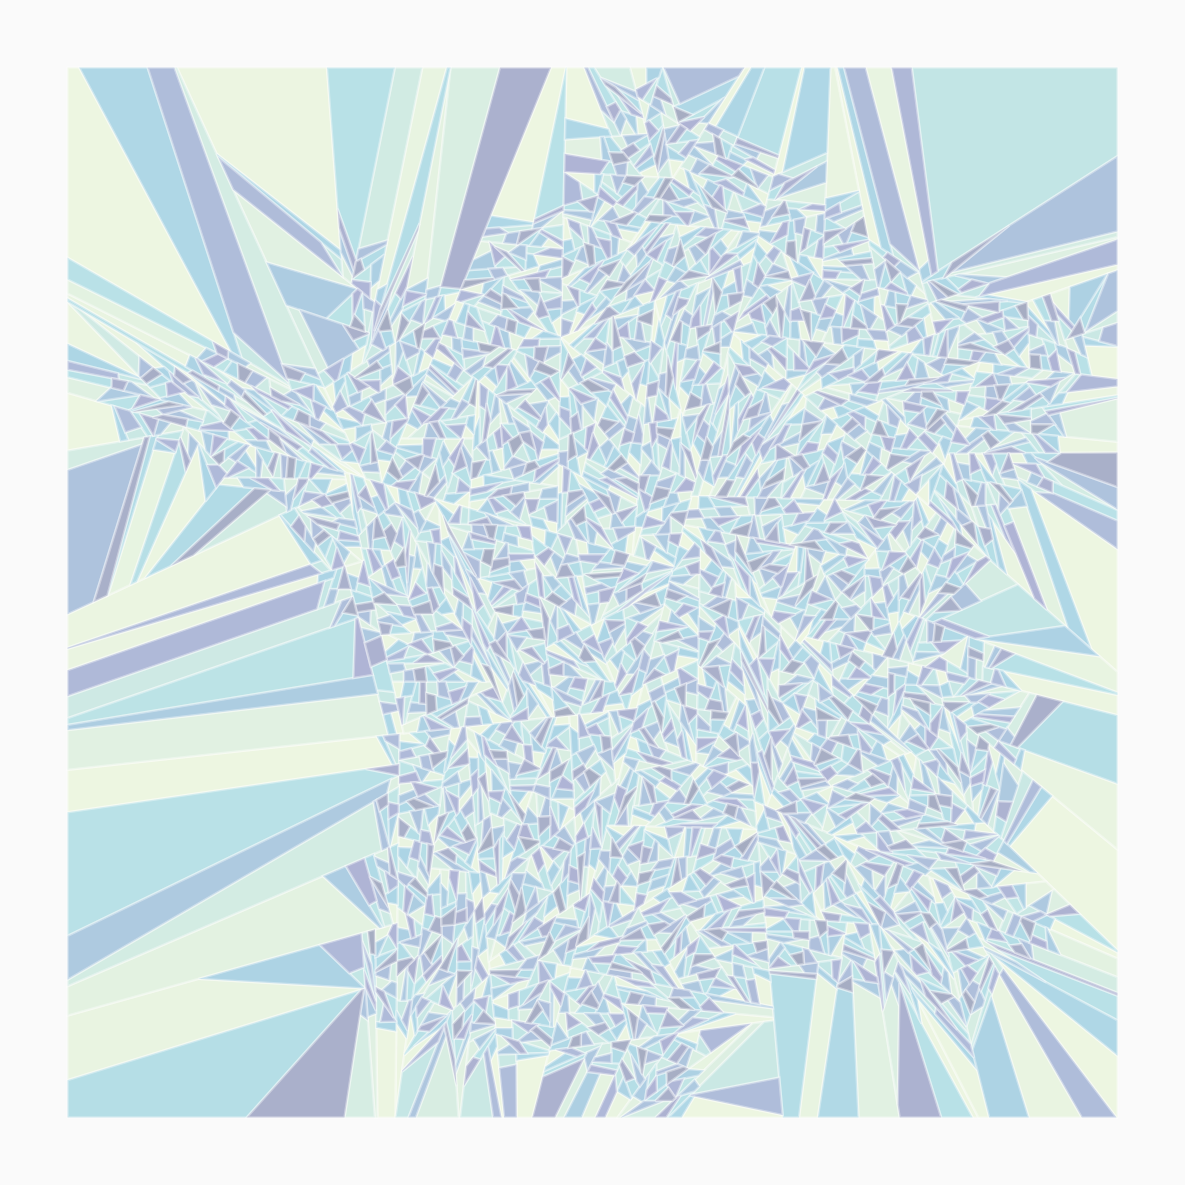

In [31]:
show_result(tessels)